Step 1: Read in, unzip, and look at the first 5 rows of the circRNA-seq



In [27]:
!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133751/suppl/GSE133751%5FmRNA%2Dexp%2Etxt%2Egz #mRNA


--2026-05-15 02:20:15--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133751/suppl/GSE133751%5FmRNA%2Dexp%2Etxt%2Egz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.13, 2607:f220:41e:250::11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2137913 (2.0M) [application/x-gzip]
Saving to: ‘GSE133751_mRNA-exp.txt.gz’

GSE133751_mRNA-exp. 100%[===================>]   2.04M  11.5MB/s    in 0.2s    

2026-05-15 02:20:16 (11.5 MB/s) - ‘GSE133751_mRNA-exp.txt.gz’ saved [2137913/2137913]



In [28]:
!gzip -d GSE133751_mRNA-exp.txt.gz


gzip: GSE133751_mRNA-exp.txt already exists; do you wish to overwrite (y or n)? n
	not overwritten


In [29]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [30]:



df = pd.read_csv("GSE133751_mRNA-exp.txt", sep="\t")

df = df.set_index("tracking_id")

df.head()

,RNA_type,Gene,Gene_type,Length,HV-2_COUNT,HV-4_COUNT,HV-6_COUNT,con-3_COUNT,con-4_COUNT,con-5_COUNT,HV-2_RPKM,HV-4_RPKM,HV-6_RPKM,con-3_RPKM,con-4_RPKM,con-5_RPKM,Website
tracking_id,,,,,,,,,,,,,,,,,
NM_000014.5,mRNA,A2M,protein_coding,4920,184,170,127,258,143,159,0.704445,0.64585,0.496837,0.996771,0.453027,0.513156,http://www.ncbi.nlm.nih.gov/nuccore/NM_000014.5
NM_000015.2,mRNA,NAT2,protein_coding,1317,7,0,0,4,6,13,0.100117,0.00000,0.000000,0.057732,0.071010,0.156738,http://www.ncbi.nlm.nih.gov/nuccore/NM_000015.2
NM_000016.5,mRNA,ACADM,protein_coding,2623,1340,941,1082,1475,1255,1006,9.622790,6.70562,7.939700,10.688900,7.457580,6.090000,http://www.ncbi.nlm.nih.gov/nuccore/NM_000016.5
NM_000017.3,mRNA,ACADS,protein_coding,1947,221,221,211,249,199,277,2.138060,2.12165,2.085890,2.430940,1.593090,2.259080,http://www.ncbi.nlm.nih.gov/nuccore/NM_000017.3
NM_000018.3,mRNA,ACADVL,protein_coding,2292,4849,5079,5035,4933,5946,5576,39.850300,41.42010,42.282400,40.910700,40.435500,38.630100,http://www.ncbi.nlm.nih.gov/nuccore/NM_000018.3


In [31]:
df.shape

(45006, 17)

Learn about the variables included

In [32]:
print(df.columns)

Index(['RNA_type', 'Gene', 'Gene_type', 'Length', 'HV-2_COUNT', 'HV-4_COUNT',
       'HV-6_COUNT', 'con-3_COUNT', 'con-4_COUNT', 'con-5_COUNT', 'HV-2_RPKM',
       'HV-4_RPKM', 'HV-6_RPKM', 'con-3_RPKM', 'con-4_RPKM', 'con-5_RPKM',
       'Website'],
      dtype='object')


Although the authors include the RPM normalized values, we want to go through the process of normalizing ourselves. So we will first subset just the _count columns of the df

In [33]:
mRNA_count_cols = [
    'con-3_COUNT',
    'con-4_COUNT',
    'con-5_COUNT',
    'HV-2_COUNT',
    'HV-4_COUNT',
    'HV-6_COUNT',
]

mRNA_RNA_raw = df[mRNA_count_cols] #Now we've subsetted just the 3 control count columns and the 3 HV count columns.

mRNA_RNA_raw.head()

,con-3_COUNT,con-4_COUNT,con-5_COUNT,HV-2_COUNT,HV-4_COUNT,HV-6_COUNT
tracking_id,,,,,,
NM_000014.5,258,143,159,184,170,127
NM_000015.2,4,6,13,7,0,0
NM_000016.5,1475,1255,1006,1340,941,1082
NM_000017.3,249,199,277,221,221,211
NM_000018.3,4933,5946,5576,4849,5079,5035


Trying the analysis again with PyDeSEQ2:

LLM prompt: using Deseq2 in python, perform a DEG analysis comparing control groups (con3, con4, and con5) versus infected groups (HV2, HV4, HV6). Obtain the log2FC, the FDRs, and filter based on |log2FC| > 1 and FDR < 0.05.

In [34]:
!pip install pydeseq2

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd

# RAW counts, samples as rows
counts = mRNA_RNA_raw.T
counts = counts.astype(int)

# Metadata dataframe
metadata = pd.DataFrame({
    'condition': ['control', 'control', 'control', 'infected', 'infected', 'infected']
}, index=counts.index)

# Run DESeq2
dds = DeseqDataSet(counts=counts, metadata=metadata, design_factors="condition")
dds.deseq2()

# Extract results
stat_res = DeseqStats(dds, contrast=["condition", "infected", "control"])
stat_res.summary()

results_mRNA_deseq = stat_res.results_df
sig_mRNA = results_mRNA_deseq[(results_mRNA_deseq['padj'] < 0.05) & (results_mRNA_deseq['log2FoldChange'].abs() > 1)]
print(f"Significant DEGs: {len(sig_mRNA)}")

sig_mRNA.head()

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_25569/2134812029.py:17: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=counts, metadata=metadata, design_factors="condition")
Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 56.29 seconds.

Fitting dispersion trend curve...
... done in 1.28 seconds.

Fitting MAP dispersions...
... done in 59.78 seconds.

Fitting LFCs...
... done in 34.26 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 12.76 seconds.



Log2 fold change & Wald test p-value: condition infected vs control
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
tracking_id                                                              
NM_000014.5   172.261105       -0.067301  0.301787 -0.223008  0.823529   
NM_000015.2     4.763826       -1.630008  1.516052 -1.075166  0.282300   
NM_000016.5  1173.494196        0.006993  0.195971  0.035683  0.971535   
NM_000017.3   228.766307        0.010876  0.210676  0.051626  0.958827   
NM_000018.3  5208.127591        0.033978  0.123615  0.274871  0.783415   
...                  ...             ...       ...       ...       ...   
NM_213726.2    33.253623       -0.113074  0.491732 -0.229950  0.818131   
NM_214461.2     1.300796       -1.358851  2.446306 -0.555471  0.578573   
NM_214462.4     1.705586        0.797111  1.919062  0.415365  0.677875   
NM_214710.4     0.160148       -0.795633  4.425556 -0.179782  0.857324   
NM_214711.3     2.378106       -1.362432  1.

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
tracking_id,,,,,,
NM_000070.2,42.743050,1.529848,0.481496,3.177278,1.486646e-03,2.586407e-02
NM_000161.2,389.385032,2.494838,0.335434,7.437643,1.024975e-13,8.902678e-12
NM_000186.3,13282.450559,1.111580,0.195032,5.699486,1.201691e-08,6.222111e-07
NM_000201.2,2366.005821,2.158397,0.308099,7.005530,2.460522e-12,1.938456e-10
NM_000215.3,78.234249,1.727858,0.456884,3.781832,1.556782e-04,3.855115e-03


In [35]:
sig_mRNA.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
tracking_id,,,,,,
NM_000070.2,42.743050,1.529848,0.481496,3.177278,1.486646e-03,2.586407e-02
NM_000161.2,389.385032,2.494838,0.335434,7.437643,1.024975e-13,8.902678e-12
NM_000186.3,13282.450559,1.111580,0.195032,5.699486,1.201691e-08,6.222111e-07
NM_000201.2,2366.005821,2.158397,0.308099,7.005530,2.460522e-12,1.938456e-10
NM_000215.3,78.234249,1.727858,0.456884,3.781832,1.556782e-04,3.855115e-03


In [36]:
sig_mRNA.shape #Gives us 788 DEGs which is super close to the 788 identified by authors!

(782, 6)

Make volcano

In [37]:
pvs   = results_mRNA_deseq['pvalue'].values
logFC = results_mRNA_deseq['log2FoldChange'].values

print("Total missing p-values:", np.isnan(pvs).sum())

Total missing p-values: 853


Remove those 0/NA p-values

In [38]:
valid  = ~np.isnan(pvs)
pvs_valid   = pvs[valid]
logFC_valid = logFC[valid]

In [39]:
fdrs_valid = results_mRNA_deseq['padj'].values[valid]

# P-value cutoff at FDR=0.05
p_fdr005     = pvs_valid[fdrs_valid < 0.05].max()
p_cutoff     = p_fdr005
logFC_cutoff = 1
print("P-value at FDR=0.05:", p_fdr005)

P-value at FDR=0.05: 0.003333871284974302


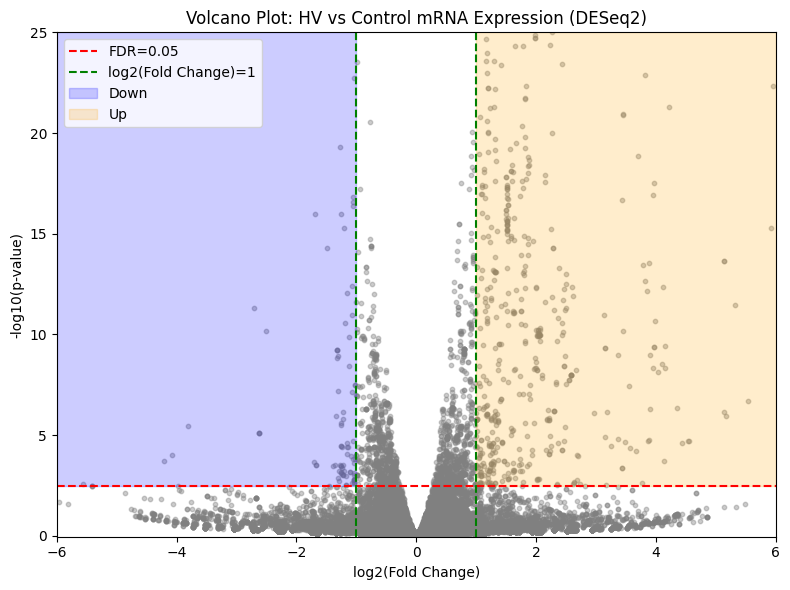

In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(logFC_valid, -np.log10(pvs_valid), alpha=0.4, c='grey', s=10)
plt.xlabel('log2(Fold Change)')
plt.ylabel('-log10(p-value)')
plt.axhline(-np.log10(p_cutoff), color='r', linestyle='--', label='FDR=0.05')
plt.axvline( logFC_cutoff,       color='g', linestyle='--', label='log2(Fold Change)=1')
plt.axvline(-logFC_cutoff,       color='g', linestyle='--')
plt.fill_between([-6, -1], [-np.log10(p_cutoff), -np.log10(p_cutoff)], [25, 25], alpha=0.2, color='blue',   label='Down')
plt.fill_between([ 1,  6], [-np.log10(p_cutoff), -np.log10(p_cutoff)], [25, 25], alpha=0.2, color='orange', label='Up')
plt.xlim(-6, 6)
plt.ylim(-0.05, 25)
plt.legend()
plt.title('Volcano Plot: HV vs Control mRNA Expression (DESeq2)')
plt.tight_layout()
plt.show()



In [41]:
#LLM prompt: tell me the names of the DEGs, and then tell me the names of the upregulated and downregulated ones
print(f"Total significant circRNAs: {len(sig_mRNA)}")
print(f"Upregulated   (log2FC >  1): {len(sig_mRNA[sig_mRNA['log2FoldChange'] >  1])}")
print(f"Downregulated (log2FC < -1): {len(sig_mRNA[sig_mRNA['log2FoldChange'] < -1])}")



Total significant circRNAs: 782
Upregulated   (log2FC >  1): 683
Downregulated (log2FC < -1): 99


TF analysis
(adapted from Dr. Hong's Enrichment Apr 29 code)

In [42]:
!pip install gseapy -q

import pandas as pd
import gseapy as gp
from gseapy import barplot, dotplot
import matplotlib.pyplot as plt

In [43]:
#LLM prompt - from the 782 mRNA degs, go back to the raw counts dataset and retrieve the gene names
# Map tracking_id to gene symbol
id_to_gene = df['Gene'].to_dict()

# Convert DEG tracking IDs to gene symbols
deg_symbols = [id_to_gene[g] for g in sig_mRNA.index if g in id_to_gene]
deg_symbols = [s for s in deg_symbols if pd.notna(s)]

print(f"Converted: {len(deg_symbols)} genes")
print(deg_symbols[:10])

Converted: 782 genes
['CAPN3', 'GCH1', 'CFH', 'ICAM1', 'JAK3', 'KIT', 'TAP2', 'TAP1', 'IL6', 'BDKRB2']


In [44]:
#Enricher - search for TFs that bind to these genes in these datasets recommended to me by AI
tf_results = gp.enrichr(
    gene_list=deg_symbols,
    gene_sets=[
        'ChEA_2022',
        'ENCODE_TF_ChIP-seq_2015',
        'TF_Perturbations_Followed_by_Expression'
    ],
    organism='human',
    outdir=None
)

tf_results.results.head(5)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,ChEA_2022,IRF1 21803131 ChIP-Seq MONOCYTES Human,57/276,1.406174e-44,1.032132e-41,0,0,17.320698,1748.920622,OGFR;UBE2L6;IFI35;IFIT1;TMEM140;IFIT3;IFIT2;IL...
1,ChEA_2022,IRF8 22096565 ChIP-ChIP GC-B Human,38/150,1.957279e-33,7.183213e-31,0,0,21.316089,1605.394635,RTP4;SP100;SAMD9;IFIT5;SECTM1;UBE2L6;IFI35;ZC3...
2,ChEA_2022,IRF8 22096565 ChIP-ChIP GC-B Mouse,57/463,7.987340e-32,1.954236e-29,0,0,9.253028,662.561837,RTP4;SECTM1;ADAR;IFI35;LSP1;IFIT1;CTSS;TNFSF13...
3,ChEA_2022,IRF1 21803131 ChIP-Seq PrimaryMonocytes Human ...,25/79,4.979244e-25,9.136914e-23,0,0,28.002115,1566.980117,SAMD9;IFI6;TRANK1;RNF19B;DDX60L;UBE2L6;IFI35;N...
4,ChEA_2022,RELA 24523406 ChIP-Seq FIBROSARCOMA Human,70/1104,2.058257e-21,3.021522e-19,0,0,4.517342,215.171977,CSF3;CXCL9;CSF2;CSF1;TNFAIP2;TNFAIP3;CXCL1;CSA...


/tmp/ipykernel_25569/4167760488.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


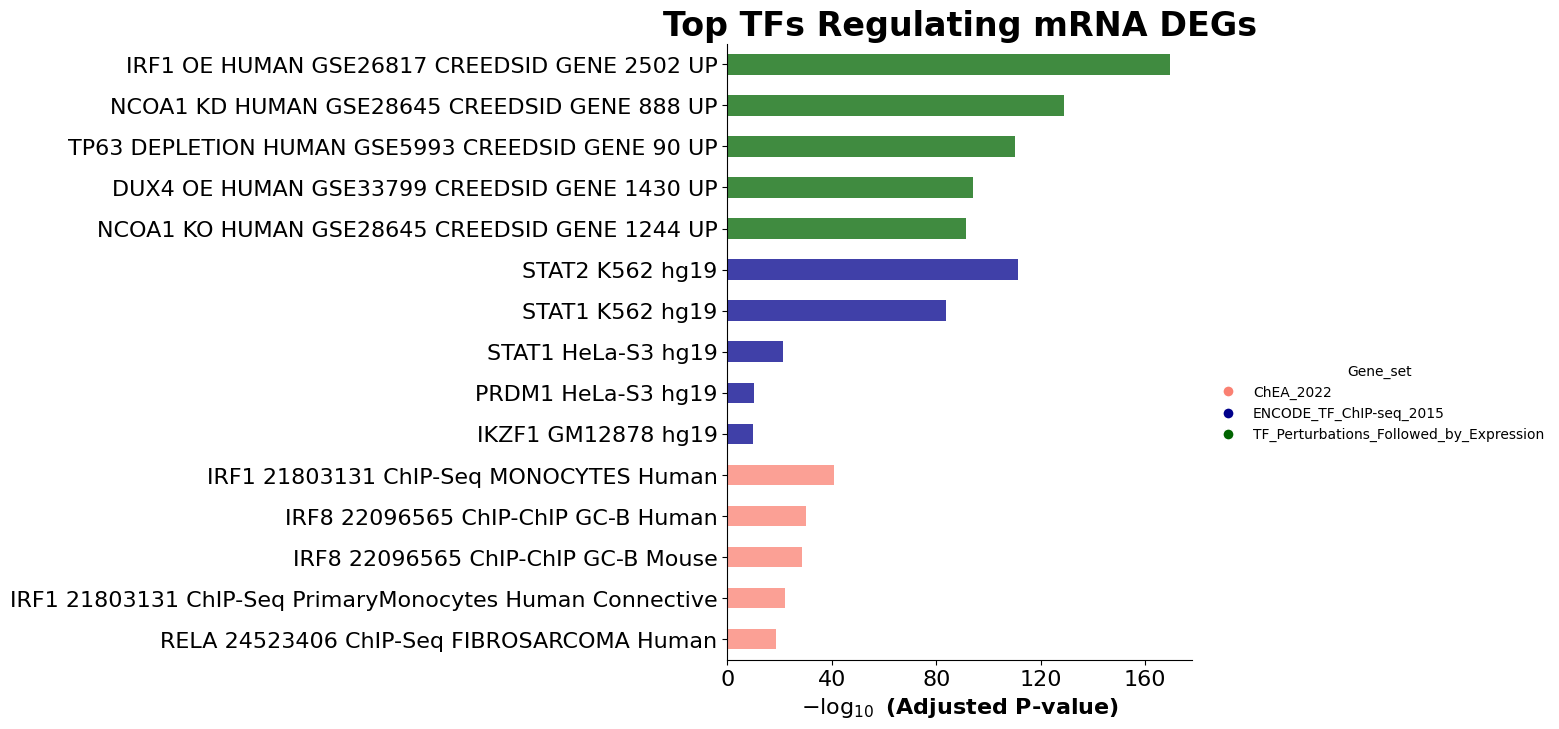

In [45]:
ax = barplot(
    tf_results.results,
    column='Adjusted P-value',
    group='Gene_set',
    title='Top TFs Regulating mRNA DEGs',
    size=10,
    top_term=5,
    figsize=(6, 8),
    color={
        'ChEA_2022': 'salmon',
        'ENCODE_TF_ChIP-seq_2015': 'darkblue',
        'TF_Perturbations_Followed_by_Expression': 'darkgreen'
    }
)
plt.tight_layout()
plt.show()

PPI analysis

In [46]:
#LLM Prompt: write me code in Python that takes the Enrichr data as the input and outputs me a list of the top 10 TFs arranged from lowest adj. P value to highest.


# Combine all TF enrichment results and pull the top 10 unique TFs
# ranked by adjusted p-value across all datasets

import pandas as pd

# Copy results dataframe
df = tf_results.results.copy()

# Sort by adjusted p-value (smallest = most significant)
df = df.sort_values("Adjusted P-value")

# Extract TF name from the 'Term' column
# (usually formatted like "STAT1 human ChIP-seq ...")
df["TF"] = df["Term"].str.split().str[0]

# Keep the best (lowest p-value) entry per TF
top_tfs = (
    df.groupby("TF", as_index=False)
      .first()
      .sort_values("Adjusted P-value")
)

# Display relevant columns
top_tfs = top_tfs[
    ["TF", "Gene_set", "Adjusted P-value", "Overlap", "Combined Score"]
]

print(top_tfs)

          TF                                 Gene_set  Adjusted P-value  \
221     IRF1  TF_Perturbations_Followed_by_Expression     2.838678e-170   
301    NCOA1  TF_Perturbations_Followed_by_Expression     1.038809e-129   
495    STAT2                  ENCODE_TF_ChIP-seq_2015     7.739503e-112   
544     TP63  TF_Perturbations_Followed_by_Expression     7.022964e-111   
92      DUX4  TF_Perturbations_Followed_by_Expression      9.261197e-95   
..       ...                                      ...               ...   
600   ZNF384                  ENCODE_TF_ChIP-seq_2015      9.999957e-01   
591    ZMIZ1                  ENCODE_TF_ChIP-seq_2015      9.999957e-01   
589  ZKSCAN1                  ENCODE_TF_ChIP-seq_2015      9.999957e-01   
38   BHLHE40                  ENCODE_TF_ChIP-seq_2015      9.999957e-01   
35    BCLAF1                  ENCODE_TF_ChIP-seq_2015      9.999957e-01   

     Overlap  Combined Score  
221  151/383    25403.582936  
301  128/390    13024.484614  
495  1

In [47]:
DEG_TFs_mRNA = top_tfs["TF"].tolist()

print(DEG_TFs_mRNA)


['IRF1', 'NCOA1', 'STAT2', 'TP63', 'DUX4', 'STAT1', 'IRX6', 'REST', 'MYB', 'PBX3', 'SPDEF', 'ZNF589', 'KLF9', 'POU1F1', 'MAF', 'IRF9', 'EGR3', 'TWIST1', 'ZEB1', 'IRF4', 'KMT2A', 'PRRX1', 'PAX5', 'LIN28', 'ZNF142', 'HES1', 'NME2', 'SP140', 'FOXM1', 'IRF8', 'HOXA11', 'PPARG', 'SETDB1', 'NR2C2', 'CTCF', 'RARA', 'TBX3', 'SOX2', 'NFE2L2', 'HSF1', 'ZMAT4', 'FOSL1', 'ZBTB7A', 'SRF', 'FOXQ1', 'OVOL2', 'HMGA2', 'VDR', 'JUN', 'NR5A2', 'ZNF253', 'RELA', 'NFIX', 'KCNIP3', 'NEUROG1', 'MYC', 'IKZF4', 'TFAP2C', 'AIRE', 'IKZF3', 'IKZF1', 'E2F2', 'TP53', 'IRF7', 'ATF6B', 'IRF5', 'GTF2I', 'POU5F1', 'BATF', 'GATA4', 'ATF3', 'STAT4', 'ERG', 'FOXD4L6', 'ADAR', 'NCOA2', 'PRDM1', 'NR3C1', 'WT1', 'GLIS2', 'STAT3', 'KLF2', 'ZHX2', 'FLI1', 'FOXD3', 'TCF3', 'KDM2B', 'ESRRA', 'EP300', 'FOXP3', 'TWIST2', 'BACH1', 'ARID3A', 'MECOM', 'DNMT1', 'PPARA', 'NFKB2', 'FOXP1', 'CEBPA', 'USF1', 'FOXA2', 'AR', 'NFE2L1', 'BCL6', 'ETS1', 'MECP2', 'GLI1', 'TSHZ3', 'PPARD', 'RXRA', 'NCOR', 'DOT1L', 'POU2AF1', 'ESR1', 'TCF4', 'FOX